
# Inhoudsopgave

1. [KaggleHub](#kagglehub)
2. [Database connect](#database-connect)
3. [De aangemaakte DataFrames](#de-aangemaakte-dataframes)
4. [Aantal rijen per DataFrame](#aantal-rijen-per-dataframe)
5. [Identifiers FC Barcelona](#identifiers-fc-barcelona)
6. [Class voor het bepalden van de ranglijst van LaLiga 2015/2016](#Class-voor-het-bepalen-van-de-ranglijst-van-LaLiga-2015/2016)
7. [Data analyse](#data-analyse)
    - [Relaties](#relaties)
        - [De Tabellen](#de-tabellen)
        - [Team_Attributes <-> Team](#team_attributes---team)
        - [Opmerkingen](#opmerkingen)

# KaggleHub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hugomathien/soccer")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\tijnd\.cache\kagglehub\datasets\hugomathien\soccer\versions\10


# Database connect

In [3]:
import sqlite3
import pandas as pd
import os

# Bepaal het pad naar de SQLite database
db_path = os.path.join(path, "database.sqlite")

# Connect met de database
conn = sqlite3.connect(db_path)

# Checkt welke tabellen er in de database zitten
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

                name
0    sqlite_sequence
1  Player_Attributes
2             Player
3              Match
4             League
5            Country
6               Team
7    Team_Attributes


# De aangemaakte DataFrames

In [4]:
print("DataFrames:")
for table_name in tables['name']:
    query = f"SELECT * FROM {table_name}"
    lower_var_name = table_name.lower()
    print(f" - {lower_var_name}")
    # Dit voegt een DataFrame toe aan de global scope met de naam van de tabel in kleine letters
    globals()[lower_var_name] = pd.read_sql(query, conn)

DataFrames:
 - sqlite_sequence
 - player_attributes
 - player
 - match
 - league
 - country
 - team
 - team_attributes


# Aantal rijen per DataFrame

In [5]:
print("Row count for each DataFrame:")
for name in tables['name']:
    name = name.lower()
    df = globals()[name]
    print(name, ":", len(df))

Row count for each DataFrame:
sqlite_sequence : 7
player_attributes : 183978
player : 11060
match : 25979
league : 11
country : 11
team : 299
team_attributes : 1458


# Identifiers FC Barcelona

In [7]:
# Zoek FC Barcelona in de team tabel
barca = team[team['team_long_name'] == 'FC Barcelona']
display(barca[['team_api_id', 
             'team_fifa_api_id', 
             'team_long_name', 
             'team_short_name']],)

# Zoek de league_id voor Spanje
spain_league = league[league['name'].str.contains("Spain")]
spain_id = spain_league['id'].values[0]

print(f"De ID voor de Spaanse La Liga is: {spain_id}")

,team_api_id,team_fifa_api_id,team_long_name,team_short_name
258,8634,241.0,FC Barcelona,BAR


De ID voor de Spaanse La Liga is: 21518


# Class voor het bepalen van de ranglijst van LaLiga 2015/2016

In [12]:
import pandas as pd

class VoetbalStand:
    def __init__(self, matches_df, teams_df):
        """Initialiseert de class met de matches en teams DataFrames."""
        self.matches = matches_df
        self.teams = teams_df

    def determine_match_stats(self, row):
        """Functie om doelsaldo en punten te bepalen voor een enkele wedstrijd."""
        home_goals = row['home_team_goal'] 
        away_goals = row['away_team_goal']
        
        # Uitkomst bepalen en punten toewijzen
        if home_goals > away_goals:
            home_points, away_points = 3, 0  # thuis winst, thuis team krijgt 3 punten, uit team krijgt 0 punten
        elif home_goals < away_goals:
            home_points, away_points = 0, 3  # uit winst, thuis team krijgt 0 punten, uit team krijgt 3 punten
        else:
            home_points, away_points = 1, 1  # gelijkspel, beide teams krijgen 1 punt

        # Doelsaldo berekenen
        home_gd = home_goals - away_goals # doelsaldo thuis
        away_gd = away_goals - home_goals # doelsaldo uit

        return pd.Series([home_points, away_points, home_gd, away_gd])

    def get_standings(self, league_id, season):
        """Verwerkt de data en geeft een gesorteerde stand terug o.b.v. punten en doelsaldo."""
        season_matches = self.matches[(self.matches['league_id'] == league_id) & (self.matches['season'] == season)].copy() # filter de matches DataFrame op de gekozen league_id en season

        stats_columns = ['home_points', 'away_points', 'home_gd', 'away_gd'] # de namen van de nieuwe kolommen die we gaan toevoegen aan season_matches
        season_matches[stats_columns] = season_matches.apply(self.determine_match_stats, axis=1) # pas de determine_match_stats functie toe op elke rij van season_matches en voeg de resultaten toe als nieuwe kolommen

        home_results = season_matches.groupby('home_team_api_id')[['home_points', 'home_gd']].sum() # group thuisresultaten op team ID en tel punten en doelsaldo op
        away_results = season_matches.groupby('away_team_api_id')[['away_points', 'away_gd']].sum() # group uitresultaten op team ID en tel punten en doelsaldo op
        
        # Voeg thuis- en uitresultaten samen
        home_away_results = pd.concat([home_results, away_results], axis= 1) # zet de home_results en away_results in één DataFrame naast elkaar
        results = pd.DataFrame() # een nieuwe DataFrame maken om de totale resultaten in op te slaan
        results['points'] = home_away_results['home_points'] + home_away_results['away_points'] # totaal punten per team, optellen van thuis- en uitpunten
        results['goal_diff'] = home_away_results['home_gd'] + home_away_results['away_gd'] # totaal doelsaldo per team, optellen van thuis- en uitdoelsaldo
        standings = results.join(self.teams.set_index('team_api_id')[['team_long_name']]) # voeg de team_long_name toe aan de standings DataFrame door te joinen op team_api_id
        
        return standings.sort_values(by=['points', 'goal_diff'], ascending=False).reset_index() # sorteer de standings, eerst op punten en daarna op doelsaldo op aflopende volgorde, en zorg dat de index weer bij 0 begint ipv de team_api_id


calculator = VoetbalStand(match, team)
la_liga_2016 = calculator.get_standings(spain_id, '2015/2016')

# Toon de top van de tabel
display(la_liga_2016[['team_long_name', 'points', 'goal_diff']])

,team_long_name,points,goal_diff
0,FC Barcelona,91,83
1,Real Madrid CF,90,76
2,Atlético Madrid,88,45
3,Villarreal CF,64,9
4,Athletic Club de Bilbao,62,13
5,RC Celta de Vigo,60,-8
6,Sevilla FC,52,1
7,Málaga CF,48,3
8,Real Sociedad,48,-3
9,Real Betis Balompié,45,-18


# Data analyse

## **Relaties**

De stippellijnen in de screenshot staan voor inactieve relaties, dit voorkomt ambiguïteit (dubbelzinnigheid) in het model, zodat PowerBI altijd 1 logisch rekenpad volgt. De verbindingen zijn nog steeds te zien in het model en zouden voor ons dus geen problemen op hoeven te leveren. Mochten we deze relaties willen gebruiken voor een visualisatie, moet hier wel rekening mee worden gehouden.

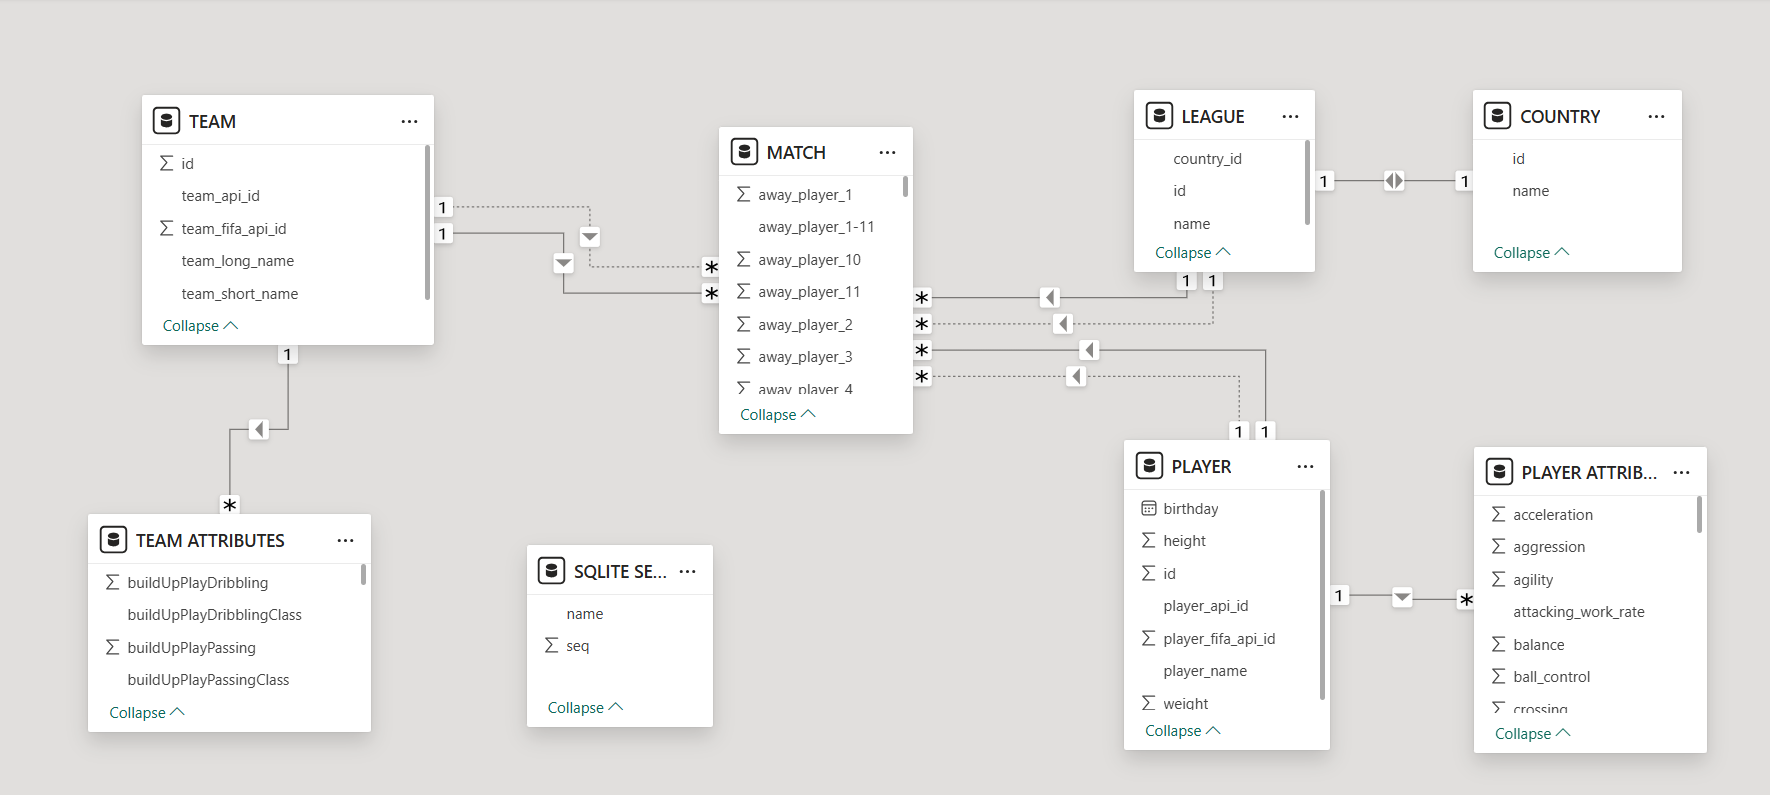

---

## **sqlite_sequence**

Er zijn in totaal **7 rijen** aan systeemgegevens in deze tabel te vinden. De dataset is volledig compleet, er zijn **geen missende waardes** aanwezig.

### **Algemene informatie**

De tabel `sqlite_sequence` is een automatisch gegenereerde beheer tabel binnen een SQLite-database die een specifieke technische rol heeft. Het zorgen voor unieke identificatienummers.

### **Kenmerken & Definities**

| Categorie | Attribuut | Type | Beschrijving | Missend | Min | Max | Gem. | Mediaan |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **Identificatie** | `name` | `text` | De specifieke naam van de tabel in de database. | 0 | Nvt | Nvt | Nvt | Nvt |
| **Teller** | `seq` | `int64` | De hoogst uitgegeven ID-waarde (sequentie) in die specifieke tabel. | 0 | 1.458 | 183.978 | 65.185,9 | 51.958,0 |

### **Relaties**

**sqlite_sequence**

De tabel `sqlite_sequence` heeft geen connectie met de andere tabellen. Dit komt omdat deze geen data bevat die een relatie heeft met voetbal, maar een interne systeemtabel van de SQLite database zelf is. Deze tabel wordt op de achtergrond gebruikt om ID-nummers bij te houden en is daarom niet gekoppeld aan de andere tabellen.


## **Player Attributes**

Er zijn in totaal **183.978 rijen** aan spelerstatistieken. De dataset is zeer uitgebreid, maar er zijn: 30 kolommen missen 836 waardes, en bij 7 kolommen missen er zelfs 2.713. De kolom `attacking_work_rate` heeft met 3.230 de meeste missende waardes.

### **Algemene informatie**

De tabel `player attributes` is de belangrijkste plek voor scores van de voetballers. Dankzij 3 verschillende Id nummers kan je dit tabel makkelijk koppelen aan de gespeelde wedstrijden van een speler en persoonlijke gegevens. 

### **Kenmerken & Definities**

| Categorie | Attribuut | Type | Beschrijving | Missend | Min | Max | Gem. | Mediaan |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **Systeem** | `id` | `int64` | De ID van de speler in de tabel. | 0 | 1 | 183.978 | 91.989,5 | 91.989,5 |
|  | `player_fifa_api_id` | `int64` | De ID van de speler in FIFA. | 0 | 2 | 234.141 | 165.671,5 | 183.488,0 |
|  | `player_api_id` | `int64` | De ID van de speler in the Open Player Database. | 0 | 2.625 | 750.584 | 135.900,6 | 77.741,0 |
|  | `date` | `object` | De datum waarop de attributen van de speler zijn opgehaald. | 0 | 2007-02-22 | 2016-07-07 | Nvt | Nvt |
| **Algemeen** | `overall_rating` | `float64` | De gemiddelde rating van de speler. | 836 | 33,0 | 94,0 | 68,60 | 69,0 |
|  | `potential` | `float64` | De maximaal haalbare rating van de speler in de toekomst. | 836 | 39,0 | 97,0 | 73,46 | 74,0 |
|  | `preferred_foot` | `object` | De voorkeur voet van de speler (Left / Right). | 836 | Nvt | Nvt | Nvt | Nvt |
|  | `attacking_work_rate` | `object` | Hoe hard de speler aanvalt (Low, Medium, High, etc.). | 3.230 | Nvt | Nvt | Nvt | Nvt |
|  | `defensive_work_rate` | `object` | Hoe hard de speler verdedigt (Low, Medium, High, etc.). | 836 | Nvt | Nvt | Nvt | Nvt |
| **Aanvallend** | `crossing` | `float64` | De score voor de voorzetten van de speler. | 836 | 1,0 | 95,0 | 55,09 | 59,0 |
|  | `finishing` | `float64` | De score voor de nauwkeurigheid van schoten op doel van de speler. | 836 | 1,0 | 97,0 | 49,92 | 53,0 |
|  | `heading_accuracy` | `float64` | De score voor de nauwkeurigheid van het koppen van de speler. | 836 | 1,0 | 98,0 | 57,27 | 60,0 |
|  | `short_passing` | `float64` | De score voor de nauwkeurigheid van de korte passen van de speler. | 836 | 3,0 | 97,0 | 62,43 | 65,0 |
|  | `volleys` | `float64` | De score voor het vermogen van de speler om een bal vanuit de lucht direct te schieten. | 2.713 | 1,0 | 93,0 | 49,47 | 52,0 |
| **Techniek** | `dribbling` | `float64` | De score voor de nauwkeurigheid van de dribbling van de speler. | 836 | 1,0 | 97,0 | 59,18 | 64,0 |
|  | `curve` | `float64` | De score voor het vermogen om de bal met een boog/effect te trappen. | 2.713 | 2,0 | 94,0 | 52,97 | 56,0 |
|  | `free_kick_accuracy` | `float64` | De score voor de nauwkeurigheid van de speler bij het nemen van directe vrije trappen. | 836 | 1,0 | 97,0 | 49,38 | 50,0 |
|  | `long_passing` | `float64` | De score voor de nauwkeurigheid van de lange passen van de speler. | 836 | 3,0 | 97,0 | 57,07 | 59,0 |
|  | `ball_control` | `float64` | De score voor het vermogen van de speler om de bal onder controle te houden. | 836 | 5,0 | 97,0 | 63,39 | 67,0 |
| **Fysiek** | `acceleration` | `float64` | De score voor hoe snel de speler zijn maximale snelheid bereikt. | 836 | 10,0 | 97,0 | 67,66 | 69,0 |
|  | `sprint_speed` | `float64` | De score voor de maximale loopsnelheid van de speler. | 836 | 12,0 | 97,0 | 68,05 | 69,0 |
|  | `agility` | `float64` | De score voor de wendbaarheid van de speler bij het draaien en veranderen van richting. | 2.713 | 11,0 | 96,0 | 65,97 | 68,0 |
|  | `reactions` | `float64` | De score voor hoe snel de speler reageert op situaties op het veld.  | 836 | 17,0 | 96,0 | 66,10 | 67,0 |
|  | `balance` | `float64` | De score voor het vermogen van de speler om zijn evenwicht te bewaren. | 2.713 | 12,0 | 96,0 | 65,19 | 67,0 |
| **Kracht** | `shot_power` | `float64` | De score voor de kracht van het schot van de speler. | 836 | 2,0 | 97,0 | 61,81 | 65,0 |
|  | `jumping` | `float64` | De score voor de sprongkracht van de speler. | 2.713 | 14,0 | 96,0 | 66,97 | 68,0 |
|  | `stamina` | `float64` | De score voor het uithoudingsvermogen van de speler. | 836 | 10,0 | 96,0 | 67,04 | 69,0 |
|  | `strength` | `float64` | De score voor de fysieke kracht van de speler. | 836 | 10,0 | 96,0 | 67,42 | 69,0 |
| **Mentale** | `long_shots` | `float64` | De score voor de nauwkeurigheid van schoten vanaf buiten het strafschopgebied. | 836 | 1,0 | 96,0 | 53,34 | 58,0 |
|  | `aggression` | `float64` | De score voor de mate van aggresie bij de speler. | 836 | 6,0 | 97,0 | 60,95 | 64,0 |
|  | `interceptions` | `float64` | De score voor het vermogen om passes te lezen en te onderscheppen van de speler. | 836 | 1,0 | 96,0 | 52,01 | 57,0 |
|  | `positioning` | `float64` | De score voor het vermogen van de speler om zich op de juist positie te positioneren. | 836 | 2,0 | 96,0 | 55,79 | 60,0 |
|  | `vision` | `float64` | De score voor het spelinzicht en overzicht om vrije medespelers en ruimtes te zien van de speler. | 2.713 | 1,0 | 97,0 | 57,87 | 60,0 |
| **Speciale** | `penalties` | `float64` | De score voor de nauwkeurigheid van het nemen van penalties van de speler. | 836 | 2,0 | 96,0 | 55,00 | 57,0 |
|  | `marking` | `float64` | De score voor het vermogen om een tegenstander af te dekken en te volgen. | 836 | 1,0 | 96,0 | 46,77 | 50,0 |
|  | `standing_tackle` | `float64` | De score voor de nauwkeurigheid van de staande tackles van de speler. | 836 | 1,0 | 95,0 | 50,35 | 56,0 |
|  | `sliding_tackle` | `float64` | De score voor de nauwkeurigheid van de slide tackles van de speler. | 2.713 | 2,0 | 95,0 | 48,00 | 53,0 |
| **Keepers** | `gk_diving` | `float64` | De score voor het vermogen van de speler om naar de hoeken te duiken en schoten te stoppen. | 836 | 1,0 | 94,0 | 14,70 | 10,0 |
|  | `gk_handling` | `float64` | De score voor het vermogen van de speler om de bal klemvast te pakken en vast te houden. | 836 | 1,0 | 93,0 | 16,06 | 11,0 |
|  | `gk_kicking` | `float64` | De score voor de afstand en nauwkeurigheid van de uittrap en passes van de de speler. | 836 | 1,0 | 97,0 | 21,00 | 12,0 |
|  | `gk_positioning` | `float64` | De score voor het vermogen van de speler om de juiste positie in het doel te kiezen. | 836 | 1,0 | 96,0 | 16,13 | 11,0 |
|  | `gk_reflexes` | `float64` | De score voor de reactiesnelheid van de speler op schoten op doel. | 836 | 1,0 | 96,0 | 16,44 | 11,0 |

### **Relaties**

**Player_Attributes <-> Player**

De tabellen `Player` en `Player_Attributes` hebben een connectie, omdat de kwaliteiten en FIFA-statistieken van een speler door de tijd heen veranderen en worden bijgehouden. Deze 2 tabellen zijn gekoppeld, doordat de kolom `player_api_id` in de `Player_Attributes` tabel verwijst naar de kolom `player_api_id` in de `Player` tabel.


### **Opmerkingen**

**Keeper data**

De keeper kolommen bevatten lage gemiddeldes en mediaanen, dit laat zien dat normale spelers ook onder deze statistieken vallen.

**Missende waardes**

De missende waardes zijn erg consistent tussen de kolommen door, we zien vaak de getallen 836 en 2.713 terugkomen. Dit laat zien dat dezelfde kolommen waarschijnlijk dezelfde waardes missen.

## **Player**

Er zijn in totaal **11.075 unieke spelers** in deze tabel te vinden. De dataset is volledig compleet, er zijn **geen missende waardes** aanwezig in de kolommen.

### **Algemene informatie**

De tabel `player` bevat de persoonlijke gegevens van alle voetballers. Deze tabel werkt als een centraal punt om namen te koppelen aan api's die je ook bij andere tabellen terugvindt. 

### **Kenmerken & Definities**

| Categorie | Attribuut | Type | Beschrijving | Missend | Min | Max | Gem. | Mediaan |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **Relatie** | `id` | `int64` | Het unieke rij-nummer in deze tabel. | 0 | 1 | 11.075 | 5.537,5 | 5.536,5 |
| **Relatie** | `player_api_id` | `int64` | De ID van de speler in the Open Player Database. | 0 | 2.625 | 750.584 | 156.582,4 | 96.619,5 |
| **Referentie** | `player_fifa_api_id` | `int64` | De unieke identifier die overeenkomt met de FIFA-games. | 0 | 2 | 234.141 | 165.664,9 | 184.671,0 |
| **Naamgeving** | `player_name` | `object` | De volledige naam van de speler. | 0 | Nvt | Nvt | Nvt | Nvt |
| **Persoonlijk** | `birthday` | `object` | Geboortedatum. | 0 | Nvt | Nvt | Nvt | Nvt |
| **Fysiek** | `height` | `float64` | De lengte van de speler in centimeters. | 0 | 157,48 | 208,28 | 181,87 | 182,88 |
| **Fysiek** | `weight` | `int64` | Het gewicht van de speler in lbs. | 0 | 117 | 243 | 168,38 | 168,0 

### **Relaties**

**Player <-> Match**

De tabellen `Match` en `Player` hebben een connectie, omdat de opstellingen de 11 basisspelers van beide teams (thuis- en uitteam) bij elke wedstrijd geregistreerd staan. Deze 2 tabellen zijn gekoppeld, doordat de speler kolommen zoals: `home_player_1-11` en `away_player_1-11` in de `Match` tabel verwijzen naar de kolom `player_api_id` in de `Player` tabel.

### **Opmerkingen**

**Conversies**

We zien dat de hoogte is berekend met centimeters terwijl het gewicht is berekend met pounds. Grote kans dat de lengte is overgezet van inches naar centimer, dit kan te zien zijn aan hele specifieke centimers (2 op de komma).

## **Match**

Er zijn in totaal **25.979 rijen** aan wedstrijdgegevens in deze tabel te vinden. Er zijn verschillende kolommen met missende waardes, zoals de home/away players die rond de ~1.800 zitten. Waar de meeste missende waardes zijn zijn de bookmakers die oplopen tot ~11.000 missende waardes.

### **Algemene informatie**

De tabel matches is het hart van de database, bijna alle tabellen komen hier wel samen. Dit is de belangrijkste plek kwa identifcatie, wie tegen wie speelde, het land en meer. 

### **Kenmerken & Definities**

| Categorie | Attribuut | Type | Beschrijving | Missend (Min - Max) | Min (Min - Max) | Max (Min - Max) | Gem. (Min - Max) | Mediaan (Min - Max) |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **Relatie** | `id` | `int64` | Het unieke rij-nummer in de tabel. | 0 | 1 | 25.979 | 12.990,0 | 12.990,0 |
| **Relatie** | `country_id` | `int64` | Id van het land waar de match gespeeld werd. | 0 | 1 | 24.558 | 11.738,6 | 10.257,0 |
| **Relatie** | `league_id` | `int64` | Id van de competitie waarin de match gespeeld werd. | 0 | 1 | 24.558 | 11.738,6 | 10.257,0 |
| **Context** | `season` | `object` | Het voetbalseizoen waarin gespeeld werd. | 0 | Nvt | Nvt | Nvt | Nvt |
| **Context** | `stage` | `int64` | De stage waar de match gespeeld werd. | 0 | 1 | 38 | 18,24 | 18,0 |
| **Context** | `date` | `object` | De datum van de match die gespeeld werd. | 0 | 2008-08-16  | 2016-05-25  | Nvt | Nvt |
| **Relatie** | `match_api_id` | `int64` | De unieke API-ID van de wedstrijd zelf. | 0 | 483.129 | 2.216.672 | 1.195.429 | 1.147.511 |
| **Relatie** | `home_team_api_id` | `int64` | De API-ID van het spelende thuisteam. | 0 | 1.601 | 274.581 | 9.984,4 | 8.697,0 |
| **Relatie** | `away_team_api_id` | `int64` | De API-ID van het spelende uitteam. | 0 | 1.601 | 274.581 | 9.984,5 | 8.697,0 |
| **Uitslag** | `home_team_goal` | `int64` | Aantal doelpunten gescoord door het thuisteam. | 0 | 0 | 10 | 1,54 | 1,0 |
| **Uitslag** | `away_team_goal` | `int64` | Aantal doelpunten gescoord door het uitteam. | 0 | 0 | 9 | 1,16 | 1,0 |
| **Positie X** | `home_player_X1-11` | `float64` | Deze geven de horizontale positie op het veld aan (de breedte) per thuis speler, elke speler heeft een ander getal achter de X. | 1.821 - 1.832 | 0,0 - 2,0 | 2,0 - 9,0 | 1,00 - 7,54 | 1,0 - 8,0 |
| **Positie X** | `away_player_X1-11` | `float64` | Deze geven de horizontale positie op het veld aan (de breedte) per uit speler, elke speler heeft een ander getal achter de X. | 1.832 - 1.839 | 1,0 - 2,0 | 6,0 - 9,0 | 1,00 - 7,53 | 1,0 - 6,0 |
| **Positie Y** | `home_player_Y1-11` | `float64` | Deze geven de verticale positie op het veld aan (de lengte van het veld) per thuis speler, elke speler heeft een ander getal achter de Y. | 1.821 - 1.832 | 0,0 - 3,0 | 3,0 - 11,00 | 1,00 - 10,44 | 1,0 - 10,0 |
| **Positie Y** | `away_player_Y1-11` | `float64` | Deze geven de verticale positie op het veld aan (de lengte van het veld) per uit speler, elke speler heeft een ander getal achter de Y. | 1.832 - 1.839 | 1,0 - 7,0 | 3,0 - 11,0 | 1,00 - 10,46 | 1,0 - 10,0 |
| **Spelers** | `home_player_1-11` | `int64` | De API-ID's van de 11 basisspelers van de thuisploeg. | 1.224 - 1.555 | 2.625 - 2.984 | 692.984 - 748.432 | 76.638,4 - 111.131,5 | 38.230,0 - 45.996,0 |
| **Spelers** | `away_player_1-11` | `int64` | De API-ID's van de 11 basisspelers van de uitploeg. |  1.234 - 1.554 | 2.625 - 2.796 | 698.273 - 748.432 | 76.628,2 - 111.087,0 | 38.289,0 - 46.212,0 |
| **Events** | `goal`, `shoton`, `shotoff` | `XML` | Log van goals, schoten op doel en schoten naast het doel. | 11.762 | Nvt | Nvt | Nvt | Nvt |
| **Events** | `foulcommit`, `card` | `XML` | Log van de overtredingen en de gegeven kaarten. | 11.762 | Nvt | Nvt | Nvt | Nvt |
| **Events** | `cross`, `corner` | `XML` | Log van de voorzetten en de hoekschoppen. | 11.762 | Nvt | Nvt | Nvt | Nvt |
| **Events** | `possession` | `XML` | Log van het ballbezit. | 11.762 | Nvt | Nvt | Nvt | Nvt |
| **Betting** | `B365H, B365D, B365A` | `float64` | Odds van **Bet365** (Thuis, Gelijk, Uit). | 3.387 | 1,04 - 1,40 | 17,0 - 51,0 | 2,63 - 4,66 | 2,10 - 3,50 |
| **Betting** | `BWH, BWD, BWA` | `float64` | Odds van **Betway** (Thuis, Gelijk, Uit). | 3.404 | 1,03 - 1,65 | 19,5 - 51,0 | 2,56 - 4,40 | 2,10 - 3,40 |
| **Betting** | `IWH, IWD, IWA` | `float64` | Odds van **Interwetten** (Thuis, Gelijk, Uit). | 3.459 | 1,03 - 1,50 | 11,0 - 25,0 | 2,47 - 4,15 | 2,10 - 3,30 |
| **Betting** | `LBH, LBD, LBA` | `float64` | Odds van **Ladbrokes** (Thuis, Gelijk, Uit). | 3.423 | 1,04 - 1,40 | 19,0 - 51,0 | 2,54 - 4,39 | 2,10 - 3,40 |
| **Betting** | `PSH, PSD, PSA` | `float64` | Odds van **Pinnacle** (Thuis, Gelijk, Uit). | 14.811 | 1,04 - 2,20 | 29,0 - 47,5 | 2,82 - 4,97 | 2,20 - 3,61 |
| **Betting** | `WHH, WHD, WHA` | `float64` | Odds van **William Hill** (Thuis, Gelijk, Uit). | 3.408 | 1,02 - 1,08 | 17,0 - 51,0 | 2,58 - 4,48 | 2,15 - 3,40 |
| **Betting** | `SJH, SJD, SJA` | `float64` | Odds van **Stan James** (Thuis, Gelijk, Uit). | 8.882 | 1,04 - 1,40 | 15,0 - 41,0 | 2,57 - 4,62 | 2,10 - 3,50 |
| **Betting** | `VCH, VCD, VCA` | `float64` | Odds van **VC Bet** (Thuis, Gelijk, Uit). | 3.411 | 1,03 - 1,62 | 26,0 - 67,0 | 2,67 - 4,84 | 2,15 - 3,50 |
| **Betting** | `GBH, GBD, GBA` | `float64` | Odds van **Gamebookers** (Thuis, Gelijk, Uit). | 11.817 | 1,05 - 1,45 | 11,0 - 34,0 | 2,50 - 4,35 | 2,10 - 3,40 |
| **Betting** | `BSH, BSD, BSA` | `float64` | Odds van **Blue Square** (Thuis, Gelijk, Uit). | 11.818 | 1,04 - 1,33 | 13,0 - 34,0 | 2,50 - 4,41 | 2.10 - 3,40 |

### **Relaties**

**Match <-> League**

De tabellen `Match` en `League` hebben een connectie, omdat elke wedstrijd onderdeel is van een specifieke competitie. Deze 2 tabellen zijn gekoppeld, doordat de kolom `league_id` in de `Match` tabel verwijst naar de kolom id in de `League` tabel.

**Match <-> Country**

De tabellen `Match` en `Country` hebben een connectie, omdat elke wedstrijd in een bepaald land wordt gespeeld. Deze 2 tabellen zijn gekoppeld, doordat de kolom `country_id` in de `Match` tabel verwijst naar de kolom id in de `Country` tabel.

### **Opmerkingen**

**Home advantage**

Bij `home_team_goal` zie je dat het gemiddelde 1,54 is en bij `away_team_goal` zie je dat het gemiddelde 1,16 is. Dit laat zien dat home advantage wel echt invloed heeft op het aantal goals dat een team maakt.

**XML Logs**

Deze rijen missen onwijs veel data, dit laat zien dat er niet voor elke match data is opgeslagen in een XML bestand.

**Bookmakers**

Verschillende bookmakers hebben verschillende missende waardes, zo zien we dat Bet365 veel minder mist dan Gamebookers. Dit heeft waarschijnlijk te maken met hoe groot de bedrijven zijn. Hier kan Bet365 voor veel meer wedstrijden iets aanbieden.

## **League**

Er zijn in totaal **11 rijen** aan competities in deze tabel te vinden. De dataset is volledig compleet, er zijn **geen missende waardes** aanwezig.

### **Algemene informatie**

De tabel `league` zorgt voor de koppeling tussen de competities en landen. Deze dataset is heel overzichtelijk dat elk land een eigen competitie heeft.

### **Kenmerken & Definities**

| Categorie | Attribuut | Type | Beschrijving | Missend | Min | Max | Gem. | Mediaan |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **Relatie** | `id` | `int64` | Het unieke rij-nummer in deze tabel. | 0 | 1 | 24.558 | 12.452,1 | 13.274,0 |
| **Relatie** | `country_id` | `int64` | De ID van de land waar de match gespeeld werd. | 0 | 1 | 24.558 | 12.452,1 | 13.274,0 |
| **Naamgeving** | `name` | `object` | De volledige naam van de competitie. | 0 | Nvt | Nvt | Nvt | Nvt |


### **Relaties**

**Match <-> League**

De tabellen `Match` en `League` hebben een connectie, omdat elke wedstrijd onderdeel is van een specifieke competitie. Deze 2 tabellen zijn gekoppeld, doordat de kolom `league_id` in de `Match` tabel verwijst naar de kolom `id` in de `League` tabel.

**Country <-> League**

De tabellen `Country` en `League` hebben een connectie met elkaar, omdat elk land een competitie heeft. Deze 2 tabellen zijn gekoppeld, doordat de kolom `country_id` in de `League` tabel verwijst naar de kolom `id` in de `Country` tabel.

## **Country**

Er zijn in totaal **11 unieke landen** in deze tabel te vinden. De dataset is volledig compleet, er zijn **geen missende waardes** aanwezig.

### **Algemene informatie**

De tabel `country` bevat de gegevens van alle landen in de database. De tabel is vooral bedoeld voor identificatie om de landen te koppelen aan id's.

### **Kenmerken & Definities**

| Categorie | Attribuut | Type | Beschrijving | Missend | Min | Max | Gem. | Mediaan |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **Relatie** | `id` | `int64` | Het unieke rij-nummer in deze tabel. | 0 | 1 | 24.558 | 12.452,1 | 13.274,0 |
| **Naamgeving** | `name` | `object` | De volledige naam van het land. | 0 | Nvt | Nvt | Nvt | Nvt |

### **Relaties**

**Country <-> League**

De tabellen `Country` en `League` hebben een connectie met elkaar, omdat elk land een competitie heeft. Deze 2 tabellen zijn gekoppeld, doordat de kolom `country_id` in de `League` tabel verwijst naar de kolom id in de `Country` tabel.

**Match <-> Country**

De tabellen Match en Country hebben een connectie, omdat elke wedstrijd in een bepaald land wordt gespeeld. Deze 2 tabellen zijn gekoppeld, doordat de kolom country_id in de Match tabel verwijst naar de kolom id in de Country tabel.

## **Team**

Er zijn in totaal **299 unieke teams** in deze tabel te vinden. De dataset is grotendeels compleet, met uitzondering van  `team_fifa_api_id`. Deze kolom bevatnamelijk 11 missende waardes (zo een 3,7%).

### **Algemene informatie**

De tabel `team` bevat de gegevens van alle voetbalclubs in de database. Ook deze tabel is bedoeld om de namen van de clubs te koppelen aan id's.

### **Kenmerken & Definities**

| Categorie | Attribuut | Type | Beschrijving | Missend | Min | Max | Gem. | Mediaan |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **Relatie** | `id` | `int64` | Het unieke rij-nummer in deze tabel. | 0 | 1 | 51.606 | 23.735,3 | 22.805,0 |
| **Relatie** | `team_api_id` | `int64` | De API-ID van het team. | 0 | 1.601 | 274.581 | 12.340,5 | 8.655,0 |
| **Referentie** | `team_fifa_api_id` | `float64` | De API-ID van het fifa team. | 11 | 1,0 | 112.513 | 21.534,3 | 673,5 |
| **Naamgeving** | `team_long_name` | `object` | De volledige naam van de voetbalclub. | 0 | Nvt | Nvt | Nvt | Nvt |
| **Naamgeving** | `team_short_name` | `object` | De afkorting van de clubnaam. | 0 | Nvt | Nvt | Nvt | Nvt |

### **Relaties**

**Team <-> Match**

De tabellen `Match` en `Team` hebben een connectie met elkaar, omdat aan elke wedstrijd twee teams meedoen: een thuisploeg en een uitploeg. Deze 2 tabellen zijn gekoppeld, doordat de kolommen `home_team_api_id` en `away_team_api_id` in de `Match` tabel verwijzen naar de primaire sleutel `team_api_id` in de `Team` tabel.

**Team_Attributes <->  Team**

De tabellen Team en Team_Attributes hebben een connectie, 
omdat de speelstijl en statistieken van een club per seizoen worden vastgelegd. Deze 2 tabellen zijn gekoppeld, doordat de kolom team_api_id in de Team_Attributes tabel verwijst naar de kolom team_api_id in de Team tabel.

### **Opmerkingen**

**Fifa API**

We zien dat 11 clubs niet zijn toegevoegd aan de Fifa lijst terwijl deze wel een naam hebben. 

## **Team Attributes**

Er zijn in totaal **1458 rijen** aan team attributes. De dataset is grotendeels compleet, met uitzondering van `buildUpPlayDribbling`, deze kolom bevat namelijk missende waardes (zo een  66%).

### **Algemene informatie**

De tabel `team attributes` zorgt voor de statistieken van de clubs en hoe ze spelen.

### **Kenmerken & Definities**

| Categorie | Attribuut | Type | Beschrijving | Missend | Min | Max | Gem. | Mediaan |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **Systeem** | `id` | `int64` | Het unieke rij-nummer in deze tabel. | 0 | 1 | 1.458 | 729,5 | 729,5 |
| | `team_fifa_api_id` | `int64` | De API-ID van het fifa team. | 0 | 1 | 112.513 | 17.707,0 | 485,0 |
| | `team_api_id` | `int64` | De API-ID van het team. | 0 | 1.601 | 274.581 | 9.995,7 | 8.674,0 |
| **Opbouw** | `buildUpPlaySpeed` | `int64` | Snelheid van de spelopbouw (0 = Traag, 100 = Snel). | 0 | 20,0 | 80,0 | 52,46 | 52,0 |
|  | `buildUpPlayDribbling` | `float64` | Mate van dribbelen (0 = Weinig, 100 = Veel). | 969 | 24,0 | 77,0 | 48,61 | 49,0 |
|  | `buildUpPlayPassing` | `int64` | Afstand van passing (0 = Kort/Dichtbij, 100 = Lang/Ver). | 0 | 20,0 | 80,0 | 48,49 | 50,0 |
|  | `buildUpPlayPositioning` | `object` | Structuur: **Organised** (vaste posities) of **Free Form**. | 0 | Nvt | Nvt | Nvt | Nvt |
| **Kansen** | `chanceCreationPassing` | `int64` | Kansen met passes (0 = Veilig, 100 = Risicovol/Risky). | 0 | 21,0 | 80,0 | 52,17 | 52,0 |
|  | `chanceCreationCrossing` | `int64` | Frequentie van voorzetten (0 = Zelden, 100 = Veel). | 0 | 20,0 | 80,0 | 53,73 | 53,0 |
|  | `chanceCreationShooting` | `int64` | Kansen om op doel te schieten (0 = Weinig, 100 = Veel). | 0 | 22,0 | 80,0 | 53,97 | 53,0 |
|  | `chanceCreationPosition` | `object` | Structuur voorin: **Organised** of **Free Form**. | 0 | Nvt | Nvt | Nvt | Nvt |
| **Defensie** | `defencePressure` | `int64` | Hoogte van druk zetten op verdediging (0 = Deep, 100 = High/Hoog). | 0 | 23,0 | 72,0 | 46,02 | 45,0 |
|  | `defenceAggression` | `int64` | Stijl van verdedigen (0 = Contain/Afwachten, 100 = Double/Agressief). | 0 | 24,0 | 72,0 | 49,25 | 48,0 |
|  | `defenceTeamWidth` | `int64` | Breedte van het verdedigend team (0 = Narrow/Smal, 100 = Wide/Breed). | 0 | 29,0 | 73,0 | 52,19 | 52,0 |
|  | `defenceDefenderLine` | `object` | Strategie: **Cover** (rugdekking) of **Offside Trap** (buitenspel). | 0 | Nvt | Nvt | Nvt | Nvt |

### **Relaties**

**Team_Attributes <->  Team**

De tabellen `Team` en `Team_Attributes` hebben een connectie, omdat de speelstijl en statistieken van een club per seizoen worden vastgelegd. Deze 2 tabellen zijn gekoppeld, doordat de kolom `team_api_id` in de `Team_Attributes` tabel verwijst naar de kolom `team_api_id` in de `Team` tabel.

### **Opmerkingen**

**buildUpPlayDribbling**

We zien dat deze kolom zo een 969 missende waardes heeft. Dit kan meerdere mogelijkheden hebben. Een match kan dit niet geregristreerd hebben, maar als je kijkt naar de data met datums erbij zie je dat in het begin dit nog niet geregristeerd werd. Pas na een moment werd dit geregristreerd. 